In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size="5" color="red">01 머신러닝 입문 Linear Regression</font>
# 1. 기존 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erro error ; 절대값평균)
- https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
- 경사하강법 설명
- https://www.mql5.com/ko/articles/11200

In [11]:
# 섭씨 온도를 화씨온도를 출력
def celsius_to_faherenheit(c):
    return c * 1.8 + 32

In [12]:
input_c = int(input('섭씨온도 ?'))
print('화씨온도는', celsius_to_faherenheit(input_c))

섭씨온도 ?1
화씨온도는 33.8


# 2. 머신러닝 프로그램 방식
```
1. 데이터 확보 및 생성
2. 데이터 전처리 : 
    스케일 조정
    훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋로 분할
3. 모델구성
4. 모델 학습과정 설정
5. 모델 학습 시키기
6. 모델 평가(시험데이터셋으로)
7. 모델 저장 및 사용(입력값이 주어지면 예측값 받기)

```
## 2.1 노이즈가 없는 데이터로 실습

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# 1. 데이터 생성
data_C = np.arange(100) #0 부터 99까지
data_C # 독립변수(입력변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [15]:
data_F = celsius_to_faherenheit(data_C)
data_F # 종속변수(타겟변수, 출력변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [16]:
# 2. 데이터 전처리 :  컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C / 100.0
scaled_data_F = data_F / 100.0
print('학습시 독립변수 : ', scaled_data_C)
print('학습시 타겟변수 : ', scaled_data_F)

학습시 독립변수 :  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
학습시 타겟변수 :  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688

In [17]:
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

In [18]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 Layer 층 지정

model = Sequential()
# model.add(Input(shape=(1,)))
# model.add(Dense(1))
model.add(Dense(units = 1, # 타겟(종속) 변수의 갯수
                input_shape=(1,))) # 입력(독립) 변수의 shape                

In [19]:
# 4. 모델 학습과정 설정
model.compile(loss="mse",         # 손실함수 - 모델 학습 중 오차를 최소화하기 위해 사용
             optimizer="rmsprop", # 옵티마이저
             metrics=['mae'])     # 평가지표
# mse : 오차 제곱의 평균
# mae : 오차 절대값의 평균(이상치 영향이 감소)
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [20]:
# 학습전 예측
model.predict(np.array([[0],
                       [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇 도?

1/1 [==============================] - 0s 71ms/step


array([[ 0.       ],
       [-0.0150233]], dtype=float32)

In [21]:
# 학습전 모델 저장
model.save('model/before_learning.h5')

In [22]:
# 5. 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, # 입력변수(훈련데이터)
                scaled_data_F, # 타겟변수(훈련데이터)
                epochs=1000, # 학습횟수
                verbose=2) # 학습시 출력여부(0:학습내용출력 X)

Epoch 1/1000
4/4 - 0s - loss: 4.7073 - mae: 1.9498 - 333ms/epoch - 83ms/step
Epoch 2/1000
4/4 - 0s - loss: 4.6582 - mae: 1.9379 - 10ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 4.6275 - mae: 1.9307 - 9ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 4.5975 - mae: 1.9236 - 10ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 4.5707 - mae: 1.9172 - 9ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 4.5449 - mae: 1.9112 - 10ms/epoch - 3ms/step
Epoch 7/1000
4/4 - 0s - loss: 4.5179 - mae: 1.9046 - 9ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 4.4928 - mae: 1.8985 - 8ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 4.4715 - mae: 1.8934 - 12ms/epoch - 3ms/step
Epoch 10/1000
4/4 - 0s - loss: 4.4478 - mae: 1.8877 - 8ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 4.4213 - mae: 1.8813 - 7ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 4.3971 - mae: 1.8754 - 8ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 4.3722 - mae: 1.8694 - 7ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - lo

Epoch 110/1000
4/4 - 0s - loss: 2.3877 - mae: 1.3100 - 10ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 2.3702 - mae: 1.3045 - 9ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 2.3543 - mae: 1.2992 - 8ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 2.3389 - mae: 1.2943 - 7ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 2.3226 - mae: 1.2890 - 7ms/epoch - 2ms/step
Epoch 115/1000
4/4 - 0s - loss: 2.3073 - mae: 1.2841 - 9ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 2.2922 - mae: 1.2792 - 7ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 2.2747 - mae: 1.2734 - 7ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 2.2593 - mae: 1.2683 - 7ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 2.2414 - mae: 1.2627 - 7ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 2.2245 - mae: 1.2572 - 8ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 2.2072 - mae: 1.2516 - 7ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 2.1912 - mae: 1.2463 - 8ms/epoch - 2ms/step
Epoch 123/1

Epoch 218/1000
4/4 - 0s - loss: 0.9712 - mae: 0.8048 - 8ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.9615 - mae: 0.8007 - 8ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.9515 - mae: 0.7966 - 6ms/epoch - 1ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.9425 - mae: 0.7930 - 6ms/epoch - 1ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.9330 - mae: 0.7891 - 7ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.9242 - mae: 0.7854 - 6ms/epoch - 1ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.9166 - mae: 0.7821 - 6ms/epoch - 1ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.9088 - mae: 0.7790 - 6ms/epoch - 1ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.9000 - mae: 0.7754 - 7ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.8896 - mae: 0.7711 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.8801 - mae: 0.7670 - 9ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.8712 - mae: 0.7631 - 7ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.8647 - mae: 0.7606 - 10ms/epoch - 2ms/step
Epoch 231/1

Epoch 326/1000
4/4 - 0s - loss: 0.3718 - mae: 0.5241 - 8ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.3696 - mae: 0.5228 - 6ms/epoch - 1ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.3670 - mae: 0.5212 - 8ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.3644 - mae: 0.5197 - 7ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.3617 - mae: 0.5178 - 8ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.3596 - mae: 0.5167 - 10ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.3577 - mae: 0.5155 - 8ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.3555 - mae: 0.5141 - 15ms/epoch - 4ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.3542 - mae: 0.5132 - 7ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.3526 - mae: 0.5122 - 9ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.3508 - mae: 0.5109 - 7ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.3483 - mae: 0.5094 - 9ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.3470 - mae: 0.5085 - 6ms/epoch - 2ms/step
Epoch 339/

Epoch 434/1000
4/4 - 0s - loss: 0.2428 - mae: 0.4259 - 6ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.2418 - mae: 0.4251 - 8ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.2407 - mae: 0.4240 - 7ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.2399 - mae: 0.4233 - 6ms/epoch - 1ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.2390 - mae: 0.4224 - 7ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.2382 - mae: 0.4216 - 6ms/epoch - 1ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.2373 - mae: 0.4209 - 8ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.2364 - mae: 0.4200 - 6ms/epoch - 1ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.2356 - mae: 0.4194 - 7ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.2346 - mae: 0.4184 - 6ms/epoch - 1ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.2339 - mae: 0.4179 - 7ms/epoch - 2ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.2329 - mae: 0.4170 - 5ms/epoch - 1ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.2321 - mae: 0.4162 - 6ms/epoch - 1ms/step
Epoch 447/10

Epoch 542/1000
4/4 - 0s - loss: 0.1524 - mae: 0.3374 - 7ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.1516 - mae: 0.3365 - 7ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.1509 - mae: 0.3356 - 7ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.1502 - mae: 0.3350 - 9ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.1495 - mae: 0.3342 - 6ms/epoch - 1ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.1488 - mae: 0.3334 - 7ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.1480 - mae: 0.3325 - 6ms/epoch - 1ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.1472 - mae: 0.3315 - 7ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.1465 - mae: 0.3307 - 7ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.1457 - mae: 0.3299 - 7ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.1450 - mae: 0.3290 - 8ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.1441 - mae: 0.3280 - 7ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.1433 - mae: 0.3271 - 8ms/epoch - 2ms/step
Epoch 555/10

Epoch 650/1000
4/4 - 0s - loss: 0.0834 - mae: 0.2488 - 7ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0830 - mae: 0.2483 - 7ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0826 - mae: 0.2476 - 7ms/epoch - 2ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0821 - mae: 0.2470 - 7ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0816 - mae: 0.2462 - 7ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0810 - mae: 0.2454 - 6ms/epoch - 1ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0804 - mae: 0.2445 - 9ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0797 - mae: 0.2435 - 8ms/epoch - 2ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0791 - mae: 0.2425 - 7ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.0785 - mae: 0.2417 - 9ms/epoch - 2ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0779 - mae: 0.2407 - 7ms/epoch - 2ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.0774 - mae: 0.2400 - 6ms/epoch - 1ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.0767 - mae: 0.2391 - 7ms/epoch - 2ms/step
Epoch 663/10

Epoch 758/1000
4/4 - 0s - loss: 0.0339 - mae: 0.1590 - 7ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0334 - mae: 0.1579 - 15ms/epoch - 4ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0331 - mae: 0.1570 - 9ms/epoch - 2ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0327 - mae: 0.1562 - 8ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0323 - mae: 0.1553 - 9ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0320 - mae: 0.1545 - 7ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0316 - mae: 0.1536 - 7ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0314 - mae: 0.1531 - 8ms/epoch - 2ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0312 - mae: 0.1525 - 7ms/epoch - 2ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0308 - mae: 0.1515 - 6ms/epoch - 1ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0306 - mae: 0.1509 - 6ms/epoch - 2ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0303 - mae: 0.1502 - 6ms/epoch - 2ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0299 - mae: 0.1495 - 6ms/epoch - 1ms/step
Epoch 771/1

Epoch 866/1000
4/4 - 0s - loss: 0.0068 - mae: 0.0713 - 7ms/epoch - 2ms/step
Epoch 867/1000
4/4 - 0s - loss: 0.0067 - mae: 0.0704 - 8ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 0.0065 - mae: 0.0696 - 7ms/epoch - 2ms/step
Epoch 869/1000
4/4 - 0s - loss: 0.0064 - mae: 0.0689 - 6ms/epoch - 1ms/step
Epoch 870/1000
4/4 - 0s - loss: 0.0063 - mae: 0.0682 - 7ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 0.0061 - mae: 0.0675 - 7ms/epoch - 2ms/step
Epoch 872/1000
4/4 - 0s - loss: 0.0060 - mae: 0.0667 - 7ms/epoch - 2ms/step
Epoch 873/1000
4/4 - 0s - loss: 0.0058 - mae: 0.0658 - 6ms/epoch - 2ms/step
Epoch 874/1000
4/4 - 0s - loss: 0.0056 - mae: 0.0648 - 8ms/epoch - 2ms/step
Epoch 875/1000
4/4 - 0s - loss: 0.0055 - mae: 0.0641 - 6ms/epoch - 1ms/step
Epoch 876/1000
4/4 - 0s - loss: 0.0053 - mae: 0.0632 - 7ms/epoch - 2ms/step
Epoch 877/1000
4/4 - 0s - loss: 0.0052 - mae: 0.0623 - 7ms/epoch - 2ms/step
Epoch 878/1000
4/4 - 0s - loss: 0.0051 - mae: 0.0615 - 7ms/epoch - 2ms/step
Epoch 879/10

Epoch 971/1000
4/4 - 0s - loss: 6.7333e-07 - mae: 7.9607e-04 - 8ms/epoch - 2ms/step
Epoch 972/1000
4/4 - 0s - loss: 3.6432e-07 - mae: 5.9036e-04 - 7ms/epoch - 2ms/step
Epoch 973/1000
4/4 - 0s - loss: 4.4499e-07 - mae: 6.4833e-04 - 8ms/epoch - 2ms/step
Epoch 974/1000
4/4 - 0s - loss: 1.3742e-06 - mae: 0.0011 - 8ms/epoch - 2ms/step
Epoch 975/1000
4/4 - 0s - loss: 3.1513e-08 - mae: 1.7175e-04 - 6ms/epoch - 1ms/step
Epoch 976/1000
4/4 - 0s - loss: 1.9653e-07 - mae: 4.2588e-04 - 8ms/epoch - 2ms/step
Epoch 977/1000
4/4 - 0s - loss: 1.4437e-06 - mae: 0.0012 - 6ms/epoch - 1ms/step
Epoch 978/1000
4/4 - 0s - loss: 4.7345e-07 - mae: 6.6246e-04 - 8ms/epoch - 2ms/step
Epoch 979/1000
4/4 - 0s - loss: 1.1715e-07 - mae: 3.3424e-04 - 6ms/epoch - 2ms/step
Epoch 980/1000
4/4 - 0s - loss: 3.8834e-07 - mae: 5.8513e-04 - 6ms/epoch - 2ms/step
Epoch 981/1000
4/4 - 0s - loss: 1.3342e-06 - mae: 0.0011 - 5ms/epoch - 1ms/step
Epoch 982/1000
4/4 - 0s - loss: 5.0223e-07 - mae: 6.8074e-04 - 6ms/epoch - 1ms/step
Epoc

In [24]:
# 6. 모델 평가 ( 그래프를 통해 loss와 metrics값의 추이, 평가함수)
print(hist.history.keys())
print(hist.history['loss'][:5])
print(hist.history['mae'][:5])

dict_keys(['loss', 'mae'])
[4.707338809967041, 4.65815544128418, 4.627511501312256, 4.597497463226318, 4.570721626281738]
[1.9497628211975098, 1.9378650188446045, 1.93071711063385, 1.923577070236206, 1.9171648025512695]


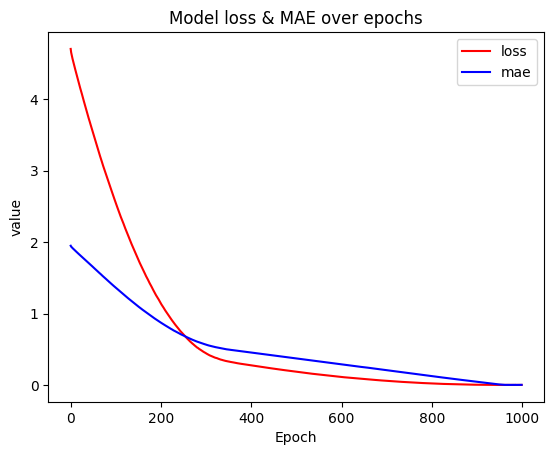

In [25]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend() # 범례 Label 추가
plt.xlabel('Epoch')
plt.ylabel('value')
plt.title('Model loss & MAE over epochs')
plt.show()

In [26]:
# 7. 모델 저장 및 사용
model.predict(np.array([[0],
                        [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 20ms/step


array([[0.32029143],
       [0.3382934 ]], dtype=float32)

In [27]:
model.save('model/after_learning.h5')

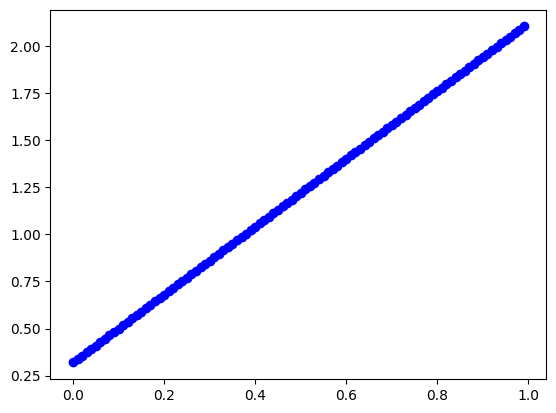

In [28]:
# 실제값
plt.scatter(x=scaled_data_C,
           y=scaled_data_F,
           c='b')
plt.show()

In [29]:
# 예측값
y_hat = model.predict([scaled_data_C])
for h, y in zip(y_hat, scaled_data_F):
    print('예측값:{}, 실제값:{}, 오차:{}'.format(h,
                                       y,
                                       h[0]-y))

4/4 [==============================] - 0s 1ms/step
예측값:[0.32029143], 실제값:0.32, 오차:0.00029142975807189275
예측값:[0.3382934], 실제값:0.33799999999999997, 오차:0.000293403387069735
예측값:[0.35629535], 실제값:0.35600000000000004, 오차:0.00029534721374507855
예측값:[0.37429732], 실제값:0.374, 오차:0.0002973208427429208
예측값:[0.3922993], 실제값:0.392, 오차:0.00029929447174070756
예측값:[0.41030124], 실제값:0.41, 오차:0.0003012382984161621
예측값:[0.4283032], 실제값:0.428, 오차:0.00030321192741394887
예측값:[0.44630516], 실제값:0.446, 오차:0.0003051557540893479
예측값:[0.46430713], 실제값:0.46399999999999997, 오차:0.0003071293830871902
예측값:[0.4823091], 실제값:0.48200000000000004, 오차:0.0003091030120849214
예측값:[0.5003111], 실제값:0.5, 오차:0.00031107664108276367
예측값:[0.51831305], 실제값:0.518, 오차:0.0003130502700805504
예측값:[0.53631496], 실제값:0.536, 오차:0.0003149642944335618
예측값:[0.55431694], 실제값:0.554, 오차:0.0003169379234313485
예측값:[0.5723189], 실제값:0.5720000000000001, 오차:0.00031891155242913527
예측값:[0.5903209], 실제값:0.59, 오차:0.00032088518142703304
예측값:[0.60832286], 실제값:

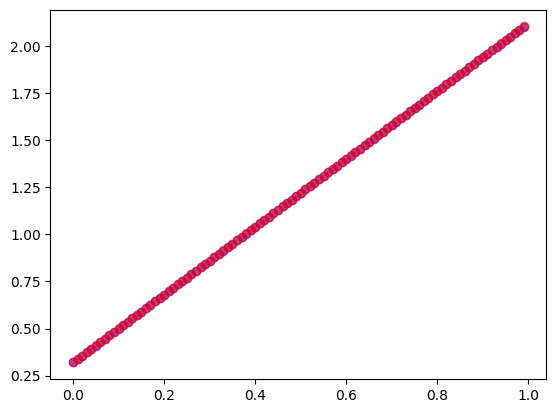

In [30]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', alpha=0.5)
plt.scatter(x=scaled_data_C, y=y_hat, c='r', alpha=0.5)

## 2.2 노이즈가 있는 데이터로 실습

In [32]:
np.random.seed(7)
noise = np.random.normal(0, scale=0.1, size=100) # 평균 0, 표준편자 0.1개 100개 데이터
noised_scaled_data_F = scaled_data_F + noise


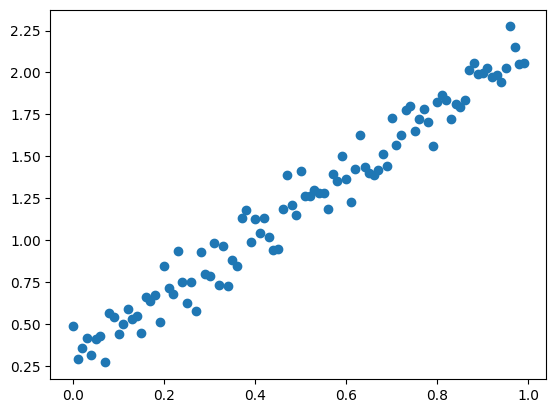

In [33]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [34]:
# 3. 모델구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
model2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [35]:
# 5. 모델 학습
hist2 = model2.fit(scaled_data_C, noised_scaled_data_F, epochs=1000, verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.2310 - mae: 1.8460
Epoch 2/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.1840 - mae: 1.8342
Epoch 3/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.1540 - mae: 1.8269
Epoch 4/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.1267 - mae: 1.8199
Epoch 5/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.0998 - mae: 1.8132
Epoch 6/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.0731 - mae: 1.8064
Epoch 7/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.0485 - mae: 1.8002
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.0267 - mae: 1.7947
Epoch 9/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.0035 - mae: 1.7886
Epoch 10/1000
4/4 [==============================] - 0s 2ms/step - loss: 3.9839 - mae: 1.7837
Epoch 11/1000
4/4 [==============================] - 0s 3ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 2.4180 - mae: 1.3291
Epoch 89/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.4006 - mae: 1.3235
Epoch 90/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.3841 - mae: 1.3182
Epoch 91/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.3680 - mae: 1.3128
Epoch 92/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.3510 - mae: 1.3072
Epoch 93/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.3342 - mae: 1.3018
Epoch 94/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.3163 - mae: 1.2959
Epoch 95/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.3011 - mae: 1.2908
Epoch 96/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.2837 - mae: 1.2852
Epoch 97/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.2659 - mae: 1.2792
Epoch 98/1000
4/4 [==============================] - 0s 2ms/step - loss: 2

4/4 [==============================] - 0s 2ms/step - loss: 1.2037 - mae: 0.8949
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1926 - mae: 0.8905
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1814 - mae: 0.8863
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1717 - mae: 0.8823
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1599 - mae: 0.8776
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1479 - mae: 0.8728
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1379 - mae: 0.8687
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1277 - mae: 0.8645
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1181 - mae: 0.8607
Epoch 183/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.1081 - mae: 0.8568
Epoch 184/1000
4/4 [==============================] - 0s 3ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.5105 - mae: 0.5957
Epoch 261/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5058 - mae: 0.5935
Epoch 262/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5007 - mae: 0.5909
Epoch 263/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4962 - mae: 0.5886
Epoch 264/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4909 - mae: 0.5860
Epoch 265/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4862 - mae: 0.5837
Epoch 266/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4812 - mae: 0.5810
Epoch 267/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.4764 - mae: 0.5785
Epoch 268/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4721 - mae: 0.5762
Epoch 269/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4675 - mae: 0.5739
Epoch 270/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.2863 - mae: 0.4605
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2853 - mae: 0.4597
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2841 - mae: 0.4586
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2832 - mae: 0.4579
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2820 - mae: 0.4568
Epoch 351/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.2811 - mae: 0.4561
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2798 - mae: 0.4550
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2786 - mae: 0.4539
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2779 - mae: 0.4534
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2767 - mae: 0.4524
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

...

4/4 [==============================] - 0s 2ms/step - loss: 0.0942 - mae: 0.2591
Epoch 605/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0938 - mae: 0.2584
Epoch 606/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0931 - mae: 0.2576
Epoch 607/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0926 - mae: 0.2567
Epoch 608/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0920 - mae: 0.2559
Epoch 609/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0915 - mae: 0.2552
Epoch 610/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0909 - mae: 0.2544
Epoch 611/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0902 - mae: 0.2534
Epoch 612/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0897 - mae: 0.2526
Epoch 613/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0891 - mae: 0.2517
Epoch 614/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0542 - mae: 0.1946
Epoch 691/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0539 - mae: 0.1938
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0536 - mae: 0.1934
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0532 - mae: 0.1928
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0529 - mae: 0.1922
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0526 - mae: 0.1916
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0523 - mae: 0.1913
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0520 - mae: 0.1905
Epoch 698/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0516 - mae: 0.1899
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0513 - mae: 0.1891
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0282 - mae: 0.1388
Epoch 777/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0280 - mae: 0.1384
Epoch 778/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0278 - mae: 0.1378
Epoch 779/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0276 - mae: 0.1374
Epoch 780/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0273 - mae: 0.1369
Epoch 781/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0271 - mae: 0.1363
Epoch 782/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0269 - mae: 0.1359
Epoch 783/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0266 - mae: 0.1351
Epoch 784/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0264 - mae: 0.1346
Epoch 785/1000
4/4 [==============================] - 0s 4ms/step - loss: 0.0262 - mae: 0.1339
Epoch 786/1000
4/4 [==============================] - 0s 3ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0146 - mae: 0.0975
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0145 - mae: 0.0968
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0145 - mae: 0.0966
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0143 - mae: 0.0962
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0142 - mae: 0.0958
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0142 - mae: 0.0957
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0141 - mae: 0.0955
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0140 - mae: 0.0951
Epoch 870/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0139 - mae: 0.0945
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0138 - mae: 0.0943
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0107 - mae: 0.0817
Epoch 949/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0107 - mae: 0.0814
Epoch 950/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0108 - mae: 0.0812
Epoch 951/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0107 - mae: 0.0811
Epoch 952/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0107 - mae: 0.0810
Epoch 953/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0107 - mae: 0.0812
Epoch 954/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0107 - mae: 0.0810
Epoch 955/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0106 - mae: 0.0810
Epoch 956/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0106 - mae: 0.0808
Epoch 957/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0106 - mae: 0.0807
Epoch 958/1000
4/4 [==============================] - 0s 3ms/step

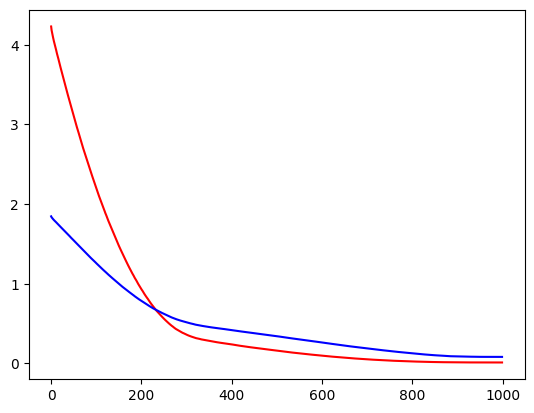

In [36]:
# 6. 학습된 모델 과정 살펴보기
plt.plot(hist2.history['loss'], c='r')
plt.plot(hist2.history['mae'], c='b')

In [43]:
model2.save('model/noise_after_learning.h5')

In [39]:
# 예측값
y_hat = model2.predict([scaled_data_C])


4/4 [==============================] - 0s 2ms/step


In [40]:
for h, y in zip(y_hat, noised_scaled_data_F):
    print("실제값:{}, 예측값:{}, 오차:{}".format(y,
                                        h,
                                        h[0]-y))

실제값:0.48905257038003563, 예측값:[0.3247417], 오차:-0.16431087902909874
실제값:0.2914062629459167, 예측값:[0.34281024], 오차:0.0514039804222321
실제값:0.3592820163678585, 예측값:[0.36087877], 오차:0.0015967492151798268
실제값:0.4147516282996508, 예측값:[0.37894732], 오차:-0.03580431069940054
실제값:0.31310769713742614, 예측값:[0.39701584], 오차:0.08390814267771363
실제값:0.4102065572905948, 예측값:[0.4150844], 오차:0.004877834541756887
실제값:0.42791096141420687, 예측값:[0.4331529], 오차:0.005241952633034341
실제값:0.2705275693654579, 예측값:[0.45122147], 오차:0.18069389669899522
실제값:0.5657658005663493, 예측값:[0.46929002], 오차:-0.09647578248468425
실제값:0.542049851591955, 예측값:[0.48735857], 오차:-0.054691281493078
실제값:0.43745710260332404, 예측값:[0.50542706], 오차:0.06796995990812005
실제값:0.5008451738804279, 예측값:[0.5234956], 오차:0.022650440648228076
실제값:0.5865299374196752, 예측값:[0.54156417], 오차:-0.044965770873807265
실제값:0.5278643584808353, 예측값:[0.55963266], 오차:0.03176830047759971
실제값:0.5477250921327455, 예측값:[0.5777012], 오차:0.029976118842901522
실제값:0.444675858750

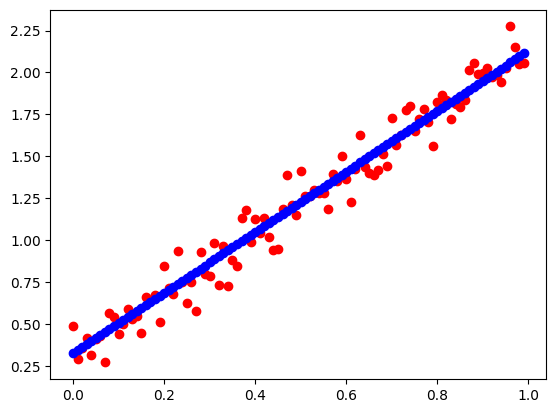

In [42]:
plt.scatter(x=scaled_data_C,
           y=noised_scaled_data_F,
           c='r')
plt.scatter(x=scaled_data_C,
           y=y_hat,
           c='b')